In [1]:
import numpy as np
from PIL import Image
import cv2
import torch
import torch.nn
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

In [2]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, img_name, transform):
        self.img_name = img_name
        self.transform = transform
        
    def __getitem__(self, index):
        img = Image.open(self.img_name)
        img = self.transform(img)
        return img
        
    def __len__(self):
        return len([self.img_name])

test_transform = transforms.Compose([transforms.Resize((256, 256)), transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])

In [3]:
def cal_thickness(mask):
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    thickness = []
    for c in range(0, mask.shape[1]):
        tcol = mask[:, c]
        if np.any(tcol != 0):
            first_non_zero_index = next((i for i, x in enumerate(tcol) if x != 0), None)
            last_non_zero_index = next((len(tcol) - i - 1 for i, x in enumerate(reversed(tcol)) if x != 0), None)
            thickness.append(last_non_zero_index - first_non_zero_index + 1)
        else:
            thickness.append(0)

    thickness = [x / (88 / 10) for x in thickness]
    non_zero_indices = np.where(np.array(thickness) != 0)[0]
    non_zero_values = np.array(thickness)[non_zero_indices]
    zero_indices = np.where(np.array(thickness) == 0)[0]
    middle_zero_indices = zero_indices[(zero_indices > non_zero_indices[0]) & (zero_indices < non_zero_indices[-1])]
    interpolated_values = np.interp(middle_zero_indices, non_zero_indices, non_zero_values)
    interpolated_data = np.array(thickness)
    interpolated_data[middle_zero_indices] = interpolated_values

    smoothed = lowess(interpolated_data[non_zero_indices[0]:non_zero_indices[-1] + 1],
                      np.arange(non_zero_indices[0], non_zero_indices[-1] + 1), frac=0.17)
    data = smoothed[100:len(thickness) - 100]
    max_value_index = np.argmax(data[:, 1])
    min_value_index = np.argmin(data[:, 1])
    peak_point = [int(data[max_value_index, 0]), data[max_value_index, 1]]
    trough_point = [int(data[min_value_index, 0]), data[min_value_index, 1]]

    x = np.arange(len(interpolated_data))
    plt.scatter(x[100:len(thickness) - 100], interpolated_data[100:len(thickness) - 100], marker='.', label='Original Data',
                color='seagreen')
    plt.plot(smoothed[100:len(thickness) - 100, 0], smoothed[100:len(thickness) - 100, 1], label='Smoothed Curve',
             color='mediumslateblue')
    plt.scatter(peak_point[0], peak_point[1], label='Peak', color='red', s=50)
    plt.scatter(trough_point[0], trough_point[1], label='Trough', color='black', s=50)
    plt.title('Diaphragm Thickness Variation Curve', fontsize=15)
    plt.legend()
    plt.xlim(0, len(interpolated_data))
    plt.yticks([])
    plt.savefig('Diaphragm Thickness Variation Curve.png')
    plt.show()
    # plt.close()

    return trough_point[1], peak_point[1], abs(peak_point[1] - trough_point[1]) / trough_point[1]


In [ ]:
test_dataset = Dataset(img_name = 'image2.png', transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
device = torch.device("cuda")
model = torch.load('segmodel2.pt')
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
model.eval()
test_img = next(iter(test_loader)).to(device)
optimizer.zero_grad()
with torch.set_grad_enabled(False):
    out_img = model(test_img)
    out_img = torch.round(out_img)[0, :, :, :].cpu()
    out_img = cv2.cvtColor((out_img.numpy() * 255).astype(np.uint8).transpose((1, 2, 0)), cv2.COLOR_RGB2BGR)

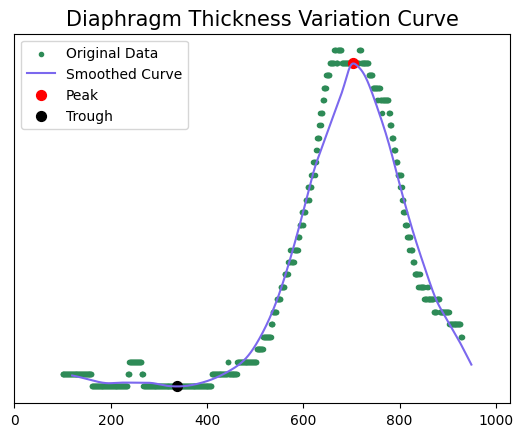

diaphragmatic thickness at the end of expiration: 2.04592032004314 (mm) 
diaphragmatic thickness at the end of inspiration: 4.99495653837514 (mm) 
diaphragm thickening fraction: 1.4414228107719351


In [5]:
img = cv2.imread('image2.png')
mask = cv2.resize(out_img, dsize=(img.shape[1], img.shape[0]), fx=1, fy=1, interpolation=cv2.INTER_LINEAR)
_, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
# cv2.imwrite('image2_seg.png', mask)
DTee, DTei, DTF = cal_thickness(mask)
print('diaphragmatic thickness at the end of expiration:', DTee, '(mm)',
      '\ndiaphragmatic thickness at the end of inspiration:', DTei, '(mm)', 
      '\ndiaphragm thickening fraction:', DTF)